# Day 6：Baseline、Suite 与 Leaderboard

今天把个人实验提升为 benchmark 实验：同一 agent 要在多个 seeds 和 splits 上运行，
用统一 metrics 和 leaderboard 比较。


In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(6)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)


project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day06


In [2]:
tu.display_learning_goal(
    6,
    "可复现实验比较",
    [
        "运行 random、scripted chemistry 和 LHS baseline。",
        "聚合 public-test 与 private-eval 的 leaderboard。",
        "理解 performance、safety-aware score 和 public-private gap。",
        "观察高产率策略为何可能被安全指标惩罚。",
    ],
)


In [3]:
tu.display_api_card()


In [4]:
tu.display_student_checkpoint(
    6,
    [
        'one trajectory table or JSONL artifact',
        'one figure generated from your own run',
        'one chemical hypothesis',
        'one proposed next experiment',
        'one note on how GPT or another assistant was used',
    ],
)


In [5]:
from chemworld.eval.leaderboard import aggregate_leaderboard
from chemworld.eval.suite import run_suite

teaching_seeds = list(range(5))
formal_benchmark_seeds = list(range(30))
agents = ['random', 'scripted_chemistry', 'lhs', 'gp_bo', 'safe_gp_bo']
suite_results = []
for agent_name in agents:
    suite_results.extend(
        run_suite(
            agent_name=agent_name,
            env_id='BatchReactorWorld',
            world_splits=['public-test', 'private-eval'],
            seeds=teaching_seeds,
            budget=66,
            objective='balanced',
            output_dir=OUTPUT_DIR / agent_name,
        )
    )

leaderboard = pd.DataFrame(aggregate_leaderboard(suite_results))
wide_leaderboard = tu.leaderboard_wide(leaderboard)
display(
    leaderboard[
        [
            'rank',
            'agent_name',
            'world_split',
            'runs',
            'mean_total_score',
            'sem_total_score',
            'ci95_total_score_low',
            'ci95_total_score_high',
            'mean_safety_aware_score',
            'public_private_gap',
        ]
    ]
)
display(wide_leaderboard)
print('Teaching run seeds:', teaching_seeds)
print('Formal benchmark target seeds:', len(formal_benchmark_seeds))


,rank,agent_name,world_split,runs,mean_total_score,sem_total_score,ci95_total_score_low,ci95_total_score_high,mean_safety_aware_score,public_private_gap
0,1,scripted_chemistry,private-eval,5,0.2352,0.0755,0.0873,0.3831,0.2894,-0.0463
1,2,gp_bo,private-eval,5,0.1895,0.0907,0.0117,0.3674,0.2198,-0.0891
2,3,safe_gp_bo,private-eval,5,0.1895,0.0907,0.0117,0.3674,0.2198,-0.0891
3,4,scripted_chemistry,public-test,5,0.1889,0.0327,0.1249,0.2529,0.2295,-0.0463
4,5,latin_hypercube,private-eval,5,0.1452,0.0473,0.0525,0.2379,0.1591,-0.0707
5,6,gp_bo,public-test,5,0.1004,0.0826,0.0000,0.2623,0.1128,-0.0891
6,7,safe_gp_bo,public-test,5,0.1004,0.0826,0.0000,0.2623,0.1128,-0.0891
7,8,latin_hypercube,public-test,5,0.0745,0.0591,0.0000,0.1904,0.0822,-0.0707
8,9,random,private-eval,5,0.0655,0.0307,0.0053,0.1257,0.0000,-0.0315
9,10,random,public-test,5,0.0340,0.0239,0.0000,0.0810,0.0000,-0.0315


,agent,public_score,private_score,public_private_gap,mean_safety_score,runs
0,scripted_chemistry,0.1889,0.2352,-0.0463,0.2594,10
1,gp_bo,0.1004,0.1895,-0.0891,0.1663,10
2,safe_gp_bo,0.1004,0.1895,-0.0891,0.1663,10
3,latin_hypercube,0.0745,0.1452,-0.0707,0.1207,10
4,random,0.0340,0.0655,-0.0315,0.0000,10


Teaching run seeds: [0, 1, 2, 3, 4]
Formal benchmark target seeds: 30


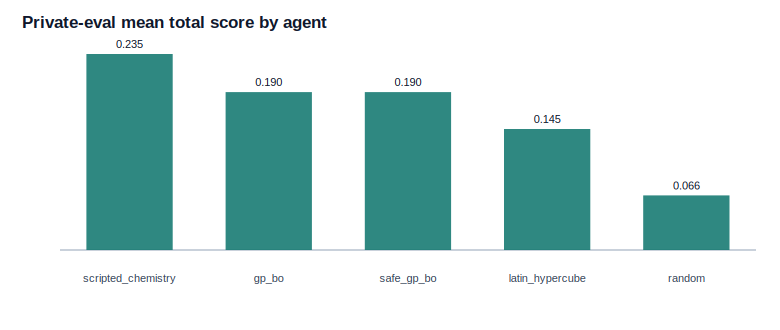

In [6]:
labels = [row.agent for row in wide_leaderboard.itertuples(index=False)]
display(
    tu.bar_svg(
        labels,
        wide_leaderboard['private_score'].astype(float).tolist(),
        title='Private-eval mean total score by agent',
        color='#0f766e',
    )
)


,label,yield,conversion,risk,score
0,safer,0.5965,0.9959,0.0866,0.469
1,risky,0.0032,0.9961,0.5388,0.000


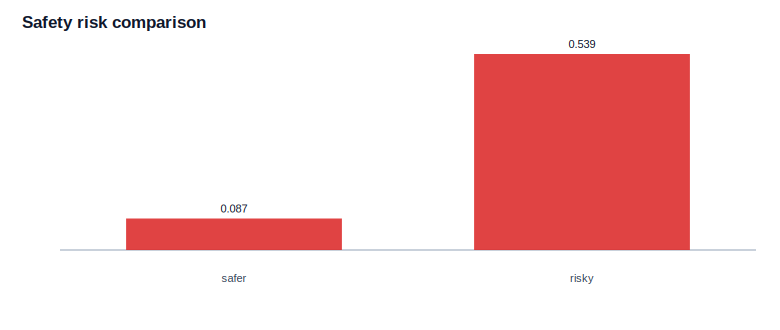

In [7]:
safe_recipe = {
    "temperature": 80.0,
    "time": 0.5,
    "initial_concentration": 0.35,
    "stirring_speed": 720.0,
    "catalyst": 1,
    "solvent": 1,
}
risky_recipe = {
    "temperature": 155.0,
    "time": 2.0,
    "initial_concentration": 1.80,
    "stirring_speed": 1000.0,
    "catalyst": 3,
    "solvent": 3,
}
risk_compare = pd.DataFrame(
    [
        dict(tu.run_recipe(safe_recipe, seed=66), label="safer"),
        dict(tu.run_recipe(risky_recipe, seed=66), label="risky"),
    ]
)
display(risk_compare[["label", "yield", "conversion", "risk", "score"]])
display(
    tu.bar_svg(
        risk_compare["label"].tolist(),
        risk_compare["risk"].astype(float).tolist(),
        title="Safety risk comparison",
        color="#dc2626",
    )
)


## 当天练习

看 leaderboard 时不要只看第一名。请选择一个 agent，回答：

- 它在 public-test 和 private-eval 上是否稳定？
- 它的 safety-aware score 是否明显低于 performance？
- 你会怎样改进它的探索策略？
